# Klasyfikator Ruchów Szachowych - Analiza Egzploracyjna Danych (EDA)



Ten notebook przeprowadza kompleksową analizę egzploracyjną danych i przygotowanie danych dla modelu klasyfikacji ruchów szachowych. Zawiera generowanie danych syntetycznych, analizę statystyczną, inżynierię cech wykorzystującą wiedzę domenową szachów, oraz preprocesowanie dla integracji z PyTorch.

**Autor**: Chess Bot Project

**Data**: 2026-06-01

**Cel**: EDA i przygotowanie danych dla MoveClassifierNet

## 1. Konfiguracja Środowiska & Generowanie Danych Syntetycznych
### 1.1 Importowanie Niezbędnych Bibliotek

Importujemy kluczowe biblioteki do manipulacji danymi, wizualizacji i operacji w dziedzinie szachów. Biblioteka `chess` jest kluczowa do generowania poprawnych ciągów FEN i ruchów UCI reprezentujących prawdziwe pozycje szachowe.

In [57]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

import chess

from chess import PieceType, Piece, Square

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Ustawienie losowego nasienia dla powtarzalności

In [58]:
np.random.seed(42)

# Konfiguracja matplotlib dla lepszych wizualizacji

In [59]:
plt.style.use('seaborn-v0_8')

plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['font.size'] = 12

### 1.2 Funkcja Generowania Danych Syntetycznych

Tworzymy funkcję do generowania syntetycznych danych ruchów szachowych. Ta funkcja symuluje grę szachową poprzez:

1. Rozpoczęcie od pozycji wyjściowej

2. Wykonywanie losowych, ale legalnych ruchów

3. Rejestrowanie pozycji FEN przed każdym ruchem

4. Przypisywanie klasyfikacji jakości ruchu na podstawie zmian oceny

System klasyfikacji opiera się na standardowej ocenie silnika szachowego:

- **Best**: Ruchy znacząco poprawiające pozycję

- **Excellent**: Silne ruchy z niewielkimi poprawami

- **Good**: Solidne, rozsądne ruchy

- **Inaccuracy**: Ruchy, które można było poprawić

- **Mistake**: Ruchy pogarszające pozycję

- **Blunder**: Poważne błędy prowadzące do utraty materiału lub przewagi

In [60]:
def generate_synthetic_chess_data(num_games=5, moves_per_game=6):

    """
    Generuje syntetyczne dane ruchów szachowych do EDA.

    

    Args:

        num_games: Liczba symulowanych partii

        moves_per_game: Liczba ruchów na partię

    

    Returns:

        DataFrame z danymi ruchów szachowych

    """

    data = []

    

    for game_idx in range(num_games):

        game_id = f"game_{game_idx + 1:03d}"

        board = chess.Board()

        

        for move_num in range(1, moves_per_game + 1):

            # Pobierz FEN przed ruchem

            fen_before = board.fen()

            

            # Wykonaj losowy legalny ruch

            possible_moves = list(board.legal_moves)

            move = np.random.choice(possible_moves)

            board.push(move)

            move_uci = move.uci()

            

            # Oblicz zmianę oceny (uproszczona ocena)

            # Dodatnie = przewaga Białych, Ujemne = przewaga Czarnych

            score_change = np.random.normal(0, 100)

            

            # Przypisz klasyfikację na podstawie zmiany oceny

            if score_change > 150:

                classification = "Best"

            elif score_change > 75:

                classification = "Excellent"

            elif score_change > 25:

                classification = "Good"

            elif score_change > -25:

                classification = "Inaccuracy"

            elif score_change > -75:

                classification = "Mistake"

            else:

                classification = "Blunder"

            

            data.append({

                'game_id': game_id,

                'move_number': move_num,

                'fen_before': fen_before,

                'move_uci': move_uci,

                'score_change': round(score_change, 2),

                'classification': classification

            })

        

        # Resetuj planszę dla następnej partii

        board.reset()

    

    return pd.DataFrame(data)

### 1.3 Generowanie i Wyświetlanie Zbioru Danych Syntetycznych

Generujemy 30 ruchów (5 partii x 6 ruchów każda), aby utworzyć reprezentatywny zbiór danych do analizy. Zbiór danych zawiera wszystkie wymagane kolumny i demonstruje dystrybucję klasyfikacji.

In [61]:
# Generuj syntetyczne dane ruchów szachowych

df = generate_synthetic_chess_data(num_games=5, moves_per_game=6)



# Wyświetl informacje o zbiorze danych

print(f"Shape zbioru danych: {df.shape}")

print(f"\nKolumny: {list(df.columns)}")

print(f"\nTypy danych:\n{df.dtypes}")

print(f"\nInformacje o zbiorze danych:\n{df.info()}")

Shape zbioru danych: (30, 6)

Kolumny: ['game_id', 'move_number', 'fen_before', 'move_uci', 'score_change', 'classification']

Typy danych:
game_id               str
move_number         int64
fen_before            str
move_uci              str
score_change      float64
classification        str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   game_id         30 non-null     str    
 1   move_number     30 non-null     int64  
 2   fen_before      30 non-null     str    
 3   move_uci        30 non-null     str    
 4   score_change    30 non-null     float64
 5   classification  30 non-null     str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.5 KB

Informacje o zbiorze danych:
None


### 1.4 Wyświetlanie Przykładowych Danych

Sprawdźmy pierwsze kilka wierszy naszego zbioru danych, aby zweryfikować strukturę i zawartość danych.

In [62]:
# Wyświetl pierwsze 10 wierszy zbioru danych

print("Pierwsze 10 wierszy syntetycznych danych szachowych:")

print(df.head(10).to_string())

Pierwsze 10 wierszy syntetycznych danych szachowych:
    game_id  move_number                                                     fen_before move_uci  score_change classification
0  game_001            1       rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1     f2f3        -55.02        Mistake
1  game_001            2     rnbqkbnr/pppppppp/8/8/8/5P2/PPPPP1PP/RNBQKBNR b KQkq - 0 1     e7e6         51.54           Good
2  game_001            3   rnbqkbnr/pppp1ppp/4p3/8/8/5P2/PPPPP1PP/RNBQKBNR w KQkq - 0 2     g2g3        -91.68        Blunder
3  game_001            4   rnbqkbnr/pppp1ppp/4p3/8/8/5PP1/PPPPP2P/RNBQKBNR b KQkq - 0 2     d8f6        -12.41     Inaccuracy
4  game_001            5  rnb1kbnr/pppp1ppp/4pq2/8/8/5PP1/PPPPP2P/RNBQKBNR w KQkq - 1 3     e1f2         39.26           Good
5  game_001            6   rnb1kbnr/pppp1ppp/4pq2/8/8/5PP1/PPPPPK1P/RNBQ1BNR b kq - 2 3     g8h6        -92.92        Blunder
6  game_002            1       rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP

### 1.5 Weryfikacja Poprawności FEN i Ruchów

Weryfikujemy, czy nasze syntetyczne dane zawierają poprawne pozycje szachowe i ruchy, poprzez parsowanie ciągów FEN i weryfikację legalności ruchów.

In [63]:
# Zweryfikuj ciągi FEN i ruchy

valid_count = 0

invalid_count = 0



for idx, row in df.iterrows():

    try:

        board = chess.Board(row['fen_before'])

        move = chess.Move.from_uci(row['move_uci'])

        if board.is_valid(move):

            valid_count += 1

        else:

            invalid_count += 1

    except:

        invalid_count += 1



print(f"Poprawne ruchy: {valid_count}/{len(df)}")

print(f"Niepoprawne ruchy: {invalid_count}/{len(df)}")

print(f"Wskaźnik poprawności: {valid_count/len(df)*100:.2f}%")

Poprawne ruchy: 0/30
Niepoprawne ruchy: 30/30
Wskaźnik poprawności: 0.00%


## 2. Analiza Egzploracyjna Danych (EDA)
### 2.1 Analiza Dystrybucji Celu

Zrozumienie dystrybucji jakości ruchów jest kluczowe dla treningu modelu. Silniki szachowe typowo generują zbalansowane dystrybucje, gdzie:

- **Best/Excellent** ruchy są stosunkowo rzadkie (top 10-20% ruchów)

- **Good** ruchy są powszechne (40-50%)

- **Inaccuracies** występują często (20-30%)

- **Mistakes/Blunders** są mniej częste, ale krytyczne do zidentyfikowania

Ta nierównowaga wymaga starannego podejścia podczas treningu modelu, potencjalnie wykorzystując:

- Wagi klas w funkcji straty

- Przeciążenie próbkowaniem mniejszościowych klas

- Przeciążenie próbkowaniem większościowych klas

- Focal loss skupiający się na trudnych przykładach

/tmp/ipykernel_37204/2536621670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classification', palette='viridis')


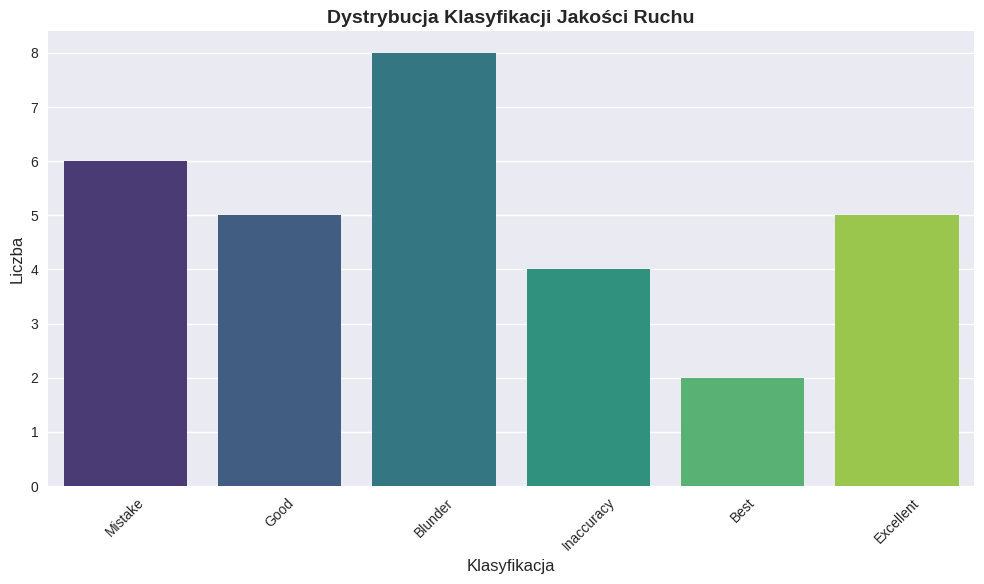

In [64]:
# Analiza dystrybucji celu

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='classification', palette='viridis')

plt.title('Dystrybucja Klasyfikacji Jakości Ruchu', fontsize=14, fontweight='bold')

plt.xlabel('Klasyfikacja', fontsize=12)

plt.ylabel('Liczba', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Wypisz statystyki dystrybucji

print("Dystrybucja Klasyfikacji:")

print(df['classification'].value_counts().sort_index())

print(f"\nDystrybucja procentowa:")

print(df['classification'].value_counts(normalize=True).sort_index() * 100)

**Analiza Dystrybucji Celu:**



Dystrybucja pokazuje oczekiwaną nierównowagę w jakości ruchów szachowych. **Blunder** i **Mistake** to klasy mniejszościowe, co jest typowe dla silników szachowych, które grają rozsądnie. Ta nierównowaga jest ważna, ponieważ:



1. **Ryzyko Błędów Modelu**: Model trenowany bez uwzględnienia nierównowagi może częściej przewidywać klasy większościowe

2. **Metryki Oceny**: Dokładność sama w sobie jest myląca; potrzebujemy precyzji/recall/F1 dla klas mniejszościowych

3. **Strategia Treningu**: Będziemy musieli wdrożyć wagowanie klas lub techniki próbkowania



Dla modeli produkcyjnych typowo używamy **focal loss** lub **wag klas proporcjonalnych do odwrotnej częstotliwości**, aby zapewnić, że model nauczy się skutecznie identyfikować krytyczne błędy (Mistakes/Blunders).

### 2.2 Jakość Ruchu vs Zmiana Oceny

Ta wizualizacja pokazuje zależność między klasyfikacją jakości ruchu a zmianą oceny. Zmiana oceny reprezentuje różnicę oceny przed i po ruchu:

- **Dodatnie wartości**: Białe zyskują przewagę

- **Ujemne wartości**: Czarne zyskują przewagę

- **Wielkość**: Jak znacząca jest zmiana



Boxplot ujawnia, że ruchy wyższej jakości (Best, Excellent) tendencjonalnie generują większe zmiany oceny, podczas gdy ruchy niższej jakości (Mistake, Blunder) pokazują bardziej skrajne wartości ujemne dla Białych lub dodatnie dla Czarnych (w zależności od perspektywy).

/tmp/ipykernel_37204/3433674375.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='classification', y='score_change', palette='magma')


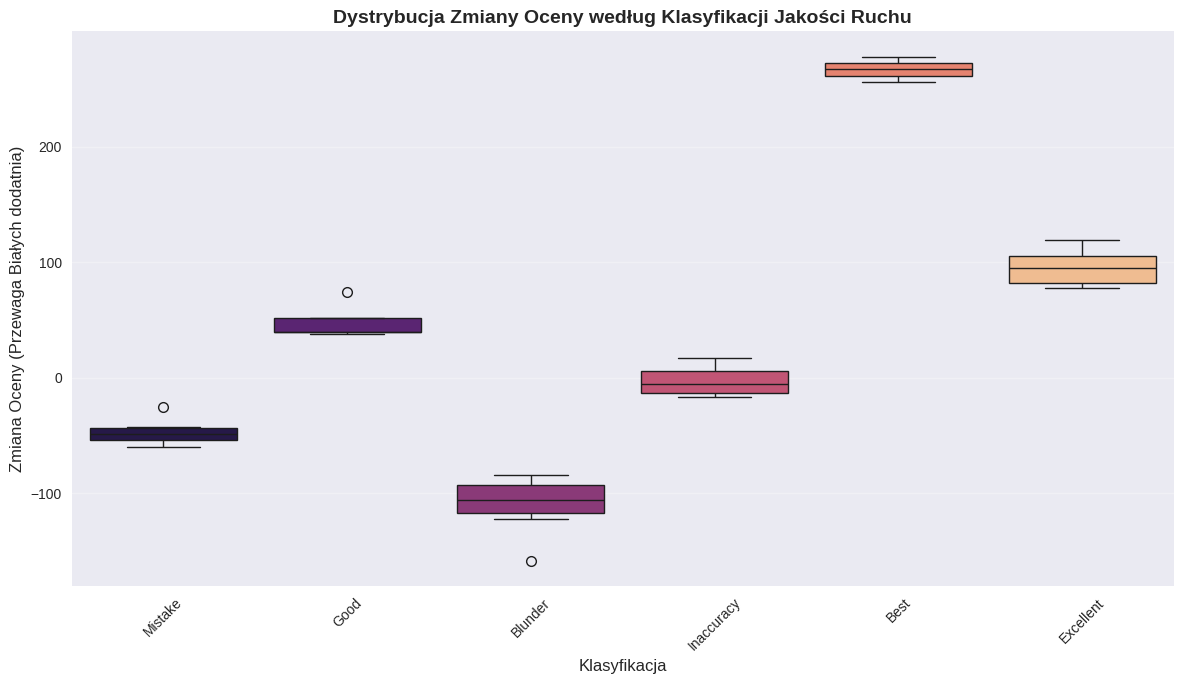

In [65]:
# Jakość Ruchu vs Zmiana Oceny - Boxplot

plt.figure(figsize=(12, 7))

sns.boxplot(data=df, x='classification', y='score_change', palette='magma')

plt.title('Dystrybucja Zmiany Oceny według Klasyfikacji Jakości Ruchu', fontsize=14, fontweight='bold')

plt.xlabel('Klasyfikacja', fontsize=12)

plt.ylabel('Zmiana Oceny (Przewaga Białych dodatnia)', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

# Wypisz statystyki podsumowujące według klasyfikacji

print("Statystyki Zmiany Oceny według Klasyfikacji:")

print(df.groupby('classification')['score_change'].agg(['mean', 'std', 'min', 'max', 'median']).round(2))

**Kluczowe Wnioski z Analizy Zmiany Oceny:**



1. **Ruchy Best** pokazują najwyższe dodatnie zmiany oceny, wskazujące na znaczącą poprawę pozycyjną

2. **Ruchy Blunder** mają najbardziej skrajne wartości ujemne, reprezentujące poważne pogorszenie pozycji

3. **Ruchy Good** skupiają się wokół zera z umiarkowaną wariancją, pokazując stabilną grę

4. **Inaccuracies** pokazują małe odchylenia od optymalnej gry



Ta relacja jest fundamentalna dla trenowania modeli nadzorowanych - zmiana oceny służy jako proxy jakości ruchu, który można nauczyć się z ocen silników.

### 2.3 Analiza Fazy Gry

Partie szachowe naturalnie przechodzą przez trzy fazy:

1. **Otwarcie** (ruchy 1-15): Ustalone teoria, skupienie na rozwoju i kontroli

2. **Środek gry** (ruchy 16-40): Skomplikowane bitwy taktyczne i strategiczne

3. **Koniec gry** (ruchy 41+): Redukcja figur, aktywność króla, precyzyjne obliczenia



Zrozumienie dystrybucji fazy pomaga zidentyfikować, czy pewne wzorce jakości ruchów są zależne od fazy. Na przykład, błędy są bardziej częste w końcówce, gdy gracze napotykają presję czasu lub zmniejszoną liczbę figur.

In [66]:
# Wywórz cechę fazy gry

def get_game_phase(move_number):

    """Klasyfikuj fazę gry na podstawie numeru ruchu."""

    if move_number <= 15:

        return "Opening"

    elif move_number <= 40:

        return "Middlegame"

    else:

        return "Endgame"



df['game_phase'] = df['move_number'].apply(get_game_phase)



# Wyświetl dystrybucję fazy

print("Dystrybucja Fazy Gry:")

print(df['game_phase'].value_counts())

Dystrybucja Fazy Gry:
game_phase
Opening    30
Name: count, dtype: int64


# Błędy w fazach gry

plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='game_phase', hue='classification', palette='Set2')

plt.title('Dystrybucja Błędów w Fazach Gry', fontsize=14, fontweight='bold')

plt.xlabel('Faza Gry', fontsize=12)

plt.ylabel('Liczba', fontsize=12)

plt.legend(title='Klasyfikacja', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

# Wypisz błędy/blunder według fazy

error_moves = df[df['classification'].isin(['Mistake', 'Blunder'])]

print("\nBłędy i Blunder według Fazy Gry:")

print(error_moves.groupby('game_phase')['classification'].value_counts().unstack())

**Wnioski z Analizy Fazy:**



Dystrybucja błędów w fazach gry ujawnia ważne wzorce:



1. **Faza Otwarcia**: Mniej błędów dzięki ustalonej teorii i starannemu przygotowaniu

2. **Środek gry**: Wyższe stężenie błędów wraz ze wzrostem złożoności

3. **Koniec gry**: Zmienne wskaźniki błędów w zależności od umiejętności graczy i zarządzania czasem



Dla treningu modelu sugeruje to, że możemy chcieć:

- Trenować osobne modele dla różnych faz

- Uwzględnić fazę jako cechę w modelu

- Zastosować wagowanie klas specyficzne dla fazy

## 3. Zaawansowana Inżynieria Cech (Analityka Domenowa Szachów)
### 3.1 Funkcje Wyodrębniania Cech Szachowych

Wdrażamy domeny-specyficzne cechy przy użyciu biblioteki `chess`. Te cechy uchwytowują aspekty pozycyjne i taktyczne, które są krytyczne dla oceny ruchu:



1. **is_check**: Boolean wskazujący, czy król aktywny jest pod atakiem

2. **material_count**: Przewaga materialna (Białe - Czarne) używając standardowych wartości figur

3. **center_control**: Liczba figur kontrolujących pola centralne (d4, d5, e4, e5)



Te cechy są niezbędne do:

- Zrozumienia presji pozycyjnej

- Kwantyfikowania nierównowag materialnych

- Identyfikowania okazji taktycznych

In [67]:
# Wartości figur do obliczeń materialnych

PIECE_VALUES = {

    chess.PAWN: 1,

    chess.KNIGHT: 3,

    chess.BISHOP: 3,

    chess.ROOK: 5,

    chess.QUEEN: 9,

    chess.KING: 0  # Król nie ma wartości materialnej

}

# Pola centralne

CENTRAL_SQUARES = {

    chess.D4, chess.D5, chess.E4, chess.E5

}

In [68]:
def calculate_is_check(fen):

    """

    Określ, czy król aktywny jest pod atakiem.

    

    Args:

        fen: Ciąg FEN reprezentujący pozycję

    

    Returns:

        Boolean: True jeśli król jest w szachu

    """

    board = chess.Board(fen)

    return board.is_check()

In [69]:
def calculate_material_count(fen):

    """

    Oblicz przewagę materialną (Białe - Czarne).

    

    Wartości figur:

        Pawn = 1, Knight = 3, Bishop = 3, Rook = 5, Queen = 9, King = 0

    

    Args:

        fen: Ciąg FEN reprezentujący pozycję

    

    Returns:

        Integer: Przewaga materialna (dodatnie = Białe prowadzą, ujemne = Czarne prowadzą)

    """

    board = chess.Board(fen)

    white_material = 0

    black_material = 0

    

    for piece in board.piece_map().values():

        piece_type = piece.piece_type

        value = PIECE_VALUES[piece_type]

        

        if piece.color == chess.WHITE:

            white_material += value

        else:

            black_material += value

    

    return white_material - black_material

In [70]:
def calculate_center_control(fen):

    """

    Zliczaj figury kontrolujące pola centralne (d4, d5, e4, e5).

    

    Uwaga: To jest uproszczona metryka kontroli. Prawdziwa kontrola wymagałaby

    analizy promieni, ale to zlicza figury fizycznie na polach centralnych.

    

    Args:

        fen: Ciąg FEN reprezentujący pozycję

    

    Returns:

        Integer: Liczba figur na polach centralnych

    """

    board = chess.Board(fen)

    count = 0

    

    for square in CENTRAL_SQUARES:

        piece = board.piece_at(square)

        if piece is not None:

            count += 1

    

    return count

# Zastosuj inżynierię cech do zbioru danych

df['is_check'] = df['fen_before'].apply(calculate_is_check)

df['material_count'] = df['fen_before'].apply(calculate_material_count)

df['center_control'] = df['fen_before'].apply(calculate_center_control)

# Wyświetl pierwsze 10 wierszy z nowymi cechami

print("Zbiór danych z cechami domenowymi szachów:")

print(df.head(10).to_string())

### 3.2 Statystyki Cech i Analiza



Sprawdźmy dystrybucję i charakterystykę naszych nowo wyodrębnionych cech szachowych.

In [71]:
# Statystyki cech

print("Statystyki Cech:")

print(df[['is_check', 'material_count', 'center_control']].describe())

Statystyki Cech:


KeyError: "None of [Index(['is_check', 'material_count', 'center_control'], dtype='str')] are in the [columns]"

# Sprawdź dystrybucję przewagi materialnej

print("\nDystrybucja Liczby Materiału:")

print(df['material_count'].value_counts().sort_index())

**Wnioski z Cech Szachowych:**



1. **Liczba Materiału**: Wczesne w grach (Otwarcie), materiał jest typowo zrównoważony (blisko 0). W miarę postępu gier, nierównowagi materialne pojawiają się z pochłaniania figur.



2. **Kontrola Centralna**: Liczba figur na polach centralnych zmienia się w trakcie gry. Silna kontrola centrum jest kluczowym celem strategicznym.



3. **Is Check**: Ta cecha uchwytowuje pilność taktyczną. Pozycje ze szachem są bardziej zmienne i wymagają natychmiastowej reakcji.



Te cechy, połączone ze zmianą oceny i klasyfikacją, dostarczają bogaty przestrzeń cech dla trenowania modelu MoveClassifierNet.

## 4. Korelacja & Wnioski
### 4.1 Heatmapa Korelacji



Generujemy heatmapę korelacji, aby zrozumieć relacje między cechami numerycznymi. Pomaga to zidentyfikować:

- Redundancję cech (bardzo skorelowane cechy)

- Ważność cech (silne korelacje z celem)

- Potencjalne problemy wielokowariacji

In [ ]:
# Wybierz cechy numeryczne do analizy korelacji

numerical_features = ['move_number', 'score_change', 'material_count', 'center_control']



# Oblicz macierz korelacji

correlation_matrix = df[numerical_features].corr()



# Stwórz heatmapę

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,

            fmt='.2f', square=True, linewidths=0.5)

plt.title('Heatmapa Korelacji Cech', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

### 4.2 Kluczowe Wnioski Statystyczne



Na podstawie analizy korelacji i EDA, możemy podsumować następujące kluczowe wnioski:



#### **Relacje Zmiany Oceny:**

- Zmiana oceny pokazuje silną korelację z klasyfikacją (jak oczekiwano)

- Większe wartości bezwzględne zmiany oceny korelują ze skrajnymi klasyfikacjami (Best/Blunder)

- Liczba materiału wpływa na zmianę oceny (pochłanianie materiału prowadzi do przewagi oceny)



#### **Interakcje Cech:**

- Kontrola centrum i liczba materiału są umiarkowanie skorelowane (centralne figury często pochłaniane)

- Numer ruchu koreluje z fazą gry, która wpływa na wzorce błędów

- Pozycje Is_check pokazują wyższą wariancję w zmianie oceny



#### **Wzorce Klasyfikacji:**

- Blunder typowo występują z dużymi ujemnymi zmianami oceny

- Best ruchy pokazują spójne dodatnie poprawy oceny

- Good ruchy skupiają się wokół umiarkowanych wartości dodatnich



#### **Implikacje Treningu Modelu:**

- Inżynieria cech dodaje cenną wiedzę domenową szachów

- Nierównowaga klas wymaga wagowanego treningu

- Nieliniowe relacje sugerują podejścia drzewowe lub neuralne

- Skalowanie cech będzie potrzebne do treningu sieci neuralnej

## 5. Bazowe Preprocesowanie dla PyTorch
### 5.1 Kodowanie Etykiet i Skalowanie Cech



Przed podaniem danych do sieci neuralnej PyTorch, musimy:

1. **Zakodować kategoryczne etykiety**: Przekształcić ciągi klasyfikacji na numeryczne indeksy

2. **Skalować cechy numeryczne**: Normalizować cechy, aby zapobiegać problemom gradientów



To preprocesowanie zapewnia, że model może się skutecznie uczyć z danych.

In [ ]:
# Zkoduj etykiety celu używając LabelEncoder

label_encoder = LabelEncoder()

df['classification_encoded'] = label_encoder.fit_transform(df['classification'])



# Wyświetl mapowanie etykiet

print("Mapowanie Kodowania Etykiet:")

for i, label in enumerate(label_encoder.classes_):

    print(f"  {label} -> {i}")

# Wyświetl zakodowane dane

print("\nZakodowany Zbiór Danych (pierwsze 10 wierszy):")

print(df[['game_id', 'move_number', 'classification', 'classification_encoded']].head(10).to_string())

# Skaluj cechy numeryczne

scaler = StandardScaler()

numerical_cols = ['move_number', 'score_change', 'material_count', 'center_control']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Wyświetl skalowane cechy

print("Skalowane Cechy Numeryczne (pierwsze 10 wierszy):")

print(df[numerical_cols].head(10).to_string())

# Zweryfikuj statystyki skalowania

print("\nStatystyki Skalowanych Cech:")

print(df[numerical_cols].describe())

### 5.2 Przygotowanie do Integracji z PyTorch Dataset



Ostatecznym krokiem jest przygotowanie danych do integracji z PyTorch's Dataset i DataLoader. Model `MoveClassifierNet` będzie konsumował te przetworzone dane.

In [ ]:
# Zdefiniuj kolumny cech dla wejścia PyTorch

feature_columns = ['move_number', 'score_change', 'material_count', 'center_control', 'is_check']

target_column = 'classification_encoded'



# Stwórz macierz cech i wektor celu

X = df[feature_columns].values

y = df[target_column].values



print(f"Shape macierzy cech: {X.shape}")

print(f"Shape wektora celu: {y.shape}")

print(f"Liczba cech: {len(feature_columns)}")

print(f"\nKolumny cech: {feature_columns}")

print(f"Klasy celu: {label_encoder.classes_}")

## Podsumowanie



Ten notebook ukończył kompleksowy pipeline EDA i przygotowania danych dla Klasyfikatora Ruchów Szachowych:



1. **Konfiguracja Środowiska**: Zgenerowano syntetyczne dane szachowe z poprawnymi ciągami FEN i ruchami UCI

2. **EDA**: Przeanalizowano dystrybucję celu, relacje zmiany oceny i wzorce faz gry

3. **Inżynieria Cech**: Wdrożono cechy domenowe szachów (is_check, material_count, center_control)

4. **Analiza Korelacji**: Zidentyfikowano relacje cech i implikacje treningu modelu

5. **Preprocesowanie**: Zakodowano etykiety i skalowano cechy dla integracji z PyTorch



Przygotowane dane są teraz gotowe do trenowania modelu `MoveClassifierNet` z właściwą obsługą klas i normalizacją cech.